# Calculate 2D electric field with $dr d\Phi$

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import jv, kv
from scipy.special import j1 # Bessel function of the first kind of order 1, for the diffraction pattern calculation
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi
import scipy.integrate as integrate

In [2]:
# jn_zeros is a function that returns the zeros of the Bessel function of the first kind, 
# which are needed to find the roots for the LP01 mode in a step-index fibre
from scipy.special import jn_zeros  # NEW: needed to get the first zero of J0

In [3]:
from scipy.optimize import brentq
from scipy.optimize import fminbound
# The Brent's method is a root-finding algorithm that combines the bisection method, the secant method, and 
# inverse quadratic interpolation. 
# https://en.wikipedia.org/wiki/Brent%27s_method
# It is designed to find roots of a continuous function within a specified interval where the function changes
#  sign. The method is efficient and robust, making it suitable for finding roots of nonlinear equations.

In [4]:
from dataclasses import dataclass

In [5]:
# %pip install joblib

In [6]:
from joblib import Parallel, delayed
import os

In [7]:
os.cpu_count()

10

In [8]:
def cutoff(l,m):
    """
    Utility  function which calculates the cutoff frequency Vc, and returns the normalised frequency (V) at cutoff V for
    a given mode l,m. 
    
    Arguments: 
    l: Azimuthal order of the LP mode, integer >= 0
    m: Radial order of the LP mode, integer >= 1
    
    Return value: 

    Vc: Normalised frequency at cutoff for the given mode, equals to the last zero of J_{l-1} for l>=1, 
    and Vc=0 for J_{m-1} for l=0.
    
    """

    if l >= 1: 
        Vc = jn_zeros(l - 1, m)[-1]
        return Vc
    elif l == 0: 
        if m == 1: 
            Vc = 0
            return Vc
        else:
            Vc = jn_zeros(1, m - 1)[-1]
            return Vc
    else:
        raise ValueError("l must be >= 0")
    

In [9]:
def modes(V, l_max=5, m_max=5, v_margin=2e-3, az_sym_only=True): 
    """
    For each value of l, calculate the allowed values of m (if any). 
    Returns a list of modes that are supported by the fibre, sorted by their cutoff V-number.

    Arguments: 
    V: Normalised frequency of the fiber, float > 0
    l_max: Maximum azimuthal order to consider, integer >= 0
    m_max: Maximum radial order to consider, integer >= 1
    v_margin: Margin for checking mode existence at cutoff, to account for numerical precision issues. 
    az_sym_only: If True, only include modes with l=0 (azimuthally symmetric modes). If False, include all modes up to l_max. 
    
    Return value: 
    mode_list: A list of [l, m, Vc] for each mode that is supported by the fibre, where Vc is the cutoff V-number for that mode. 
    """ 
    if V <= 0: 
        raise ValueError("V must be >= 0")

    mode_list = []

    for l in range(l_max + 1): 
        # if both conditions are met, we only consider modes with l=0, which are azimuthally symmetric.
        if az_sym_only and l != 0: 
            continue # skip modes with l != 0 if az_sym_only is True
        # no else needed, we just continue to the next l if the condition is met. if az_sym_only is False, we will consider all l values up to l_max, 
        # including those with l != 0.
        for m in range(1, m_max + 1): 
            V_c = cutoff(l, m) 

            if V > V_c + v_margin: 
                mode_list.append([l, m, V_c])

            else: 
                break
    
    # A lambda function is an anonymous function in Python, which can take any number of arguments but can only have one expression. 
    # In this case, the lambda function is used as the key for sorting the mode_list. 
    mode_list.sort(key=lambda mode: mode[2])  # Sort by cutoff V-number

    return mode_list

In [10]:
def function_characteristic_eq(X, V, l): 
    """
    Function that equates to zero at the roots of the characteristic equation. 

    Arguments: 
    X: Normalised transverse propagation constant in the core, float > 0
    V: Normalised frequency of the fibre, float > 0
    Return value: 
    lhs - rhs: The difference between the left-hand side and right-hand side of the characteristic equation, which should be zero at the roots. 
    """
    # Calculate Y based on the relationship Y^2 = V^2 - X^2
    Y = np.sqrt(V**2 - X**2) # Y is the normalised transverse propagation constant in the cladding, and must be real for guided modes (X < V)

    if l > 0: 
        lhs = X * jv(l + 1, X) / jv(l, X)
        rhs = Y * kv(l + 1, Y) / kv(l, Y)
        return lhs - rhs 
    
    elif l == 0:
        lhs = X * jv(1, X) / jv(0, X)
        rhs = Y * kv(1, Y) / kv(0, Y)
        return lhs - rhs
    
    else:
        raise ValueError("l must be >= 0")

In [11]:
from scipy.optimize import brentq
import numpy as np

def find_root_XY(l, m, V, eps=np.finfo(float).eps):
    """
    Calculates the two transverse propagation constants X & Y for a given
    normalised frequency and LP mode (l,m).

    Arguments:
    V: Normalised frequency, float >= cutoff(l,m)
    l: Azimuthal order of the LP mode, integer >= 0
    m: Radial order of the LP mode, integer >= 1
    eps: Margin to avoid numerical issues near cutoff

    Returned values: 
    X_root: Normalised transverse propagation constant in the core, float > 0
    Y_root: Normalised transverse propagation constant in the cladding, float > 0
    """

    # This creates a one-variable function of X only.
    # V and l are "remembered" from the surrounding function.
    f = lambda X: function_characteristic_eq(X, V, l)

    # For all except LP01, Vc is positive. LP01 has cutoff Vc = 0.
    Vc_low = cutoff(l, m)

    if V <= Vc_low: 
        raise ValueError(f"V={V:.6f} is below cutoff for mode ({l},{m})")
    
    Vc_high = cutoff(l + 1, m) # cutoff frequency of the next azimuthal mode with the same radial order
    # We set the lower bound to be slightly above Vc_low to avoid numerical issues
    lower = Vc_low * (1 + eps)
    # Set the upper bound to be slightly below allowed upper limits to avoid numerical issues
    upper = min(Vc_high * (1 - eps), V * (1 - eps)) # between the Vc of the next mode and the maximum allowed by the fibre V
    X_root = brentq(f, lower, upper) # uses lambda function f to find the root in the specified interval
    Y_root = np.sqrt(V**2 - X_root**2)

    return X_root, Y_root

## 2D E-field of misaligned fibre

Start considering the misalignment of the E-field because we can always have a deviation in alignment between the fibre and the pupil. 

### Angular part of the LP mode field

For a weakly guiding step-index fibre, an LP mode can be written as a radial part multiplied by an angular part:

$$
E_{lm}(r,\phi) = R_{lm}(r)\,f_l(\phi),
$$

where $R_{lm}(r)$ is the radial field profile and $f_l(\phi)$ describes the angular dependence.

The angular coordinate is

$$
\phi = \mathrm{atan2}(y,x).
$$

For azimuthally symmetric modes, $l=0$, the field has no angular dependence:

$$
f_0(\phi) = 1.
$$

So for LP$_{01}$,

$$
E_{01}(r,\phi) = R_{01}(r).
$$

In this case, the value of $\phi$ does not matter physically because the mode is radially symmetric.

For asymmetric modes with $l>0$, there are two orthogonal angular forms:

$$
f_l(\phi) = \cos(l\phi),
$$

or

$$
f_l(\phi) = \sin(l\phi).
$$

Therefore,

$$
E_{lm}^{(\cos)}(r,\phi) = R_{lm}(r)\cos(l\phi),
$$

and

$$
E_{lm}^{(\sin)}(r,\phi) = R_{lm}(r)\sin(l\phi).
$$

At exactly $r=0$, the angle $\phi$ is undefined. For $l=0$ this is not a problem because $f_0(\phi)=1$. For $l>0$, the asymmetric mode field should be zero at the centre, so we set

$$
f_l(0)=0 \quad \text{for } l>0.
$$

In [12]:
def lp_mode_field_2d(x, y, a, l, X_root, Y_root, angular="cos"): 
    """
    Calculate the 2D electric field distribution of an LP mode in a step-index fibre. 

    Arguments: 
    x: 2D array of x coordinates in physical units (e.g., microns)
    y: 2D array of y coordinates in physical units (e.g., microns)
    a: Core radius of the fibre, in the same units as x and y
    l: Azimuthal order of the LP mode, integer >= 0
    X_root: Normalised transverse propagation constant in the core, float > 0
    Y_root: Normalised transverse propagation constant in the cladding, float > 0

    Return value: 
    E_2d: 2D array of the electric field distribution of the specified LP mode at the given coordinates. 
    I_2d: 2D array of the intensity distribution (|E|^2) of the specified LP mode at the given coordinates.
    """

    r = np.sqrt(x**2 + y**2) # Calculate the radial distance from the center of the fibre
    phi = np.arctan2(y, x) # Calculate the angular coordinate in the 2D grid, arctan2 is tan^-1(y/x) 
    # but takes into account the signs of x and y to determine the correct quadrant 
    rho = r / a # Normalised radial coordinate

    E_mode = np.zeros_like(r, dtype=float)

    # Calculate the field distribution based on the LP mode
    # Angular part: 
    if l ==0:
        fphi = np.ones_like(phi) # For l=0, the angular part is constant so phi=0 for cos(l*phi) 
    else:
        if angular == "cos":
            fphi = np.cos(l * phi)
        elif angular == "sin": 
            fphi = np.sin(l * phi)
        else:
            raise ValueError("angular must be 'cos' or 'sin'")
        
        # At exactly r=0, the asymmetric modes should be zero
        fphi = np.where(r > 0, fphi, 0) # np.where chooses fphi where r>0, else if r!>0 it sets fphi to 0

    # Radial masks: 
    core = r <= a # Boolean mask for core region 
    cladding = r > a # Boolean mask for cladding region

    # 
    # Author's normalization convention:
    # core: J_l(u r/a) / J_l(u)
    # cladding: K_l(w r/a) / K_l(w)
    E_mode[core] = fphi[core] * jv(l, X_root * rho[core])
    
    Constant_C = jv(l, X_root) / kv(l, Y_root) # This constant ensures the field is continuous at r=a
    E_mode[cladding] = fphi[cladding] * Constant_C * kv(l, Y_root * rho[cladding]) 

    I_mode = np.abs(E_mode)**2

    return E_mode, I_mode
    


    

In [13]:
def diffraction_limited_E_field_at_fibre_2d(x, y, lam0, F_eff, alpha=0.0, E_S=1.0, decentre=None):
    """
    Diffraction-limited telescope image electric field evaluated
    on a 2D grid at the fibre input plane.

    Parameters
    ----------
    x, y : 2D arrays
        Cartesian coordinates at the fibre input plane [m].
        The fibre centre is assumed to be at x=0, y=0.
    lam0 : float
        Wavelength [m].
    F_eff : float
        Effective focal ratio at the fibre input plane.
    alpha : float
        Central obstruction ratio.
    E_S : float
        Overall field amplitude.
    decentre : None or tuple
        If None, the image is centred on the fibre.
        If (dx, dy), the image centre is shifted by dx, dy [m]
        relative to the fibre centre.

    Returns
    -------
    E_image : 2D array
        Electric field at the fibre input plane.
    I_image : 2D array
        Intensity at the fibre input plane.
    """

    if decentre is None:
        dx, dy = 0.0, 0.0
        r_image = np.sqrt(x**2 + y**2)

    else:
        dx, dy = decentre
        # Coordinates relative to the centre of the image/PSF
        x_shifted = x - dx
        y_shifted = y - dy # if we set phi=0, the vertical shift would become zero as we 
        # later set dy=rsin(phi)=r, assuming the shift is purely radial

        # The radial distance from the centre of the PSF is calculated using the coordinates
        r_image = np.sqrt(x_shifted**2 + y_shifted**2)

    # Compute s, the normalized radial coordinate in the image plane, which is used to calculate the Airy pattern.
    s = np.pi * r_image / (lam0 * F_eff)

    airy_term = np.divide(2 * j1(s), s,
        out=np.ones_like(s),
        where=s != 0
    )

    if alpha > 0:
        obstruction_term = np.divide(2 * j1(alpha * s), alpha * s,
            out=np.ones_like(s),
            where=(alpha * s) != 0
        )
        E_image = E_S * (airy_term - alpha**2 * obstruction_term)
    else:
        E_image = E_S * airy_term

    I_image = np.abs(E_image)**2

    return E_image, I_image

In [14]:
# np.meshgrid?

In [15]:
np.sin(0)

np.float64(0.0)

In [16]:
np.cos(0)

np.float64(1.0)

### 2D coupling efficiency as an overlap integral

The coupling efficiency between the image-plane electric field and a fibre mode is calculated from the coherent overlap integral:

$$
\eta =
\frac{
\left|\iint E_{\rm image}(x,y)\,E_{\rm mode}^{*}(x,y)\,dx\,dy\right|^2
}{
\left(\iint |E_{\rm image}(x,y)|^2\,dx\,dy\right)
\left(\iint |E_{\rm mode}(x,y)|^2\,dx\,dy\right)
}.
$$

The numerator is the squared overlap between the two electric fields:

$$
\mathrm{numerator}
=
\left|\iint E_{\rm image}(x,y)\,E_{\rm mode}^{*}(x,y)\,dx\,dy\right|^2.
$$

The denominator is the product of the total powers in each field:

$$
P_{\rm image}
=
\iint |E_{\rm image}(x,y)|^2\,dx\,dy,
$$

$$
P_{\rm mode}
=
\iint |E_{\rm mode}(x,y)|^2\,dx\,dy,
$$

so

$$
\mathrm{denominator}
=
P_{\rm image}P_{\rm mode}.
$$

Therefore,

$$
\eta =
\frac{
|\langle E_{\rm image}, E_{\rm mode}\rangle|^2
}{
P_{\rm image}P_{\rm mode}
}.
$$

The power integrals do not replace the overlap integral. They only normalise it, so that the efficiency is independent of the arbitrary amplitude scaling of either field.

For example, if

$$
E_{\rm image} \rightarrow A E_{\rm image},
$$

and

$$
E_{\rm mode} \rightarrow B E_{\rm mode},
$$

then the numerator becomes

$$
|AB^*|^2
\left|\iint E_{\rm image}E_{\rm mode}^{*}\,dx\,dy\right|^2,
$$

while the denominator becomes

$$
|A|^2 |B|^2
\left(\iint |E_{\rm image}|^2\,dx\,dy\right)
\left(\iint |E_{\rm mode}|^2\,dx\,dy\right).
$$

The scale factors cancel, so the coupling efficiency only measures how well the two field shapes match.

In the 2D Cartesian grid, the integrals are evaluated over area elements:

$$
dA = dx\,dy.
$$

So the continuous overlap integral

$$
\iint E_{\rm image}E_{\rm mode}^{*}\,dx\,dy
$$

is approximated numerically by summing/integrating over the grid.

In [17]:
def coupling_efficiency_2d(E_image, E_mode, x_1d, y_1d): 
    """
    Calculate the 2D coupling efficiency between an image-plane electric field
    and a fibre mode electric field.

    Input:
    E_image: 2D electric field of the image at the fibre input plane
    E_mode: 2D electric field of the fibre LP mode
    x_1d: 1D x-coordinate array used to make the 2D grid [m]
    y_1d: 1D y-coordinate array used to make the 2D grid [m]

    Output:
    eta: coupling efficiency
    numerator = |∫∫ E_image * conj(E_mode) dx dy|^2
    denominator = ∫∫ |E_image|^2 dx dy * ∫∫ |E_mode|^2 dx dy
    """

    # The integrand inside the integral
    overlap_integrand = E_image * np.conjugate(E_mode)

    # First integrate along the direction of x: 
    overlap_x = integrate.simpson(overlap_integrand, x=x_1d, axis=1)
    overlap = integrate.simpson(overlap_x, x=y_1d) 

    # Power is the integral of the electric field amplitude intensity. 
    # The power in each electric field are normalisation factors when we take the product of 
    # power in image field and power in mode field
    P_image_x = integrate.simpson(np.abs(E_image)**2, x=x_1d, axis=1)
    P_image = integrate.simpson(P_image_x, x=y_1d)
    P_mode_x = integrate.simpson(np.abs(E_mode)**2, x=x_1d, axis=1)
    P_mode = integrate.simpson(P_mode_x, x=y_1d)

    # Calculate the coupling efficiency
    numerator = np.abs(overlap)**2
    denominator = P_image * P_mode

    eta = numerator / denominator

    return eta, numerator, denominator

In [18]:
def prepare_modes_2d(
    x, y,
    a, NA, lam0,
    az_sym=True,
    mode_case="few_mode"
):
    """
    Prepare fibre mode fields for a fixed core radius.

    Parameters:
    x, y: 2D coordinate arrays at the fibre input plane [m]
    a: Core radius of the fibre [m]
    NA: Numerical aperture of the fibre
    lam0: Wavelength [m]
    az_sym: If True, only include azimuthally symmetric modes (l=0). If False, 
    include all modes up to l_max.
    mode_case:
        "smf"      -> only LP01
        "few_mode" -> all supported modes, optionally restricted by az_sym
    
    Returns value: 
    prepared_modes: A list of dictionaries containing precomputed fibre mode fields and their properties.
    Includes l, m, cutoff_V, X_root, Y_root, angular, E_mode, I_mode for each mode.
    """

    V = 2 * np.pi * a * NA / lam0

    if mode_case == "smf": # note if the maximum radius leads to V > 2.405, the fibre would support more modes, the case would be impractical
        allmodes = [[0, 1, 0.0]]
        if V > 2.405:
            print(f"Warning: V={V:.3f} > 2.405, the fibre would support more modes than just LP01, the 'smf' case may be impractical.")

    elif mode_case == "few_mode":
        allmodes = modes(V, az_sym_only=az_sym) # compute all modes supported by the fibre based on the V number

        if az_sym:
            allmodes = [mode for mode in allmodes if mode[0] == 0] # only keep azimuthally symmetric modes if az_sym is True

    else:
        raise ValueError("mode_case must be 'smf' or 'few_mode'")

    # Create a list to store the prepared modes
    prepared_modes = []
    # Loop through each mode created from modes() and compute the corresponding electric field distribution
    for mode in allmodes:
        l, m, cutoff_V = mode

        try:
            X_root, Y_root = find_root_XY(l, m, V) # find X_root and Y_root for the mode with l,m, at the given V estimated from a (not Vc)
        except ValueError:
            continue

        if l == 0:
            angular_list = ["cos"] # only one polarisaton for azimuthally symmetric modes, technically for l=0 the angular part is just a constant (cos(0)=1)
        else:
            angular_list = ["cos", "sin"] # both cos and sin polarisations for asymmetric modes

        for angular in angular_list:
            E_mode, I_mode = lp_mode_field_2d(
                x, y,
                a=a,
                l=l,
                X_root=X_root,
                Y_root=Y_root,
                angular=angular
            )

            prepared_modes.append({
                "l": l,
                "m": m,
                "cutoff_V": cutoff_V,
                "X_root": X_root,
                "Y_root": Y_root,
                "angular": angular,
                "E_mode": E_mode,
                "I_mode": I_mode
            })

    return prepared_modes

In [19]:
def total_eff_2d(
    prepared_modes,
    x, y, x_1d, y_1d,
    lam0, F_eff, alpha,
    decentre=None,
    E_S=1.0
):
    """
    Calculates the total 2D coupling efficiency using precomputed fibre modes.
    Only E_image changes with focal ratio F.

    Parameters:
    prepared_modes: A list of dictionaries containing precomputed fibre mode fields and their properties.
    x, y: 2D coordinate arrays at the fibre input plane [m]
    x_1d, y_1d: 1D coordinate arrays used to make the 2D grid [m]
    lam0: Wavelength [m]
    F_eff: Effective focal ratio to be optimised
    alpha: Divergence angle [rad]
    decentre: Decentre of the image field [m]
    E_S: Source electric field amplitude [V/m]
    """

    E_image, I_image = diffraction_limited_E_field_at_fibre_2d(
        x, y,
        lam0=lam0,
        F_eff=F_eff,
        alpha=alpha,
        E_S=E_S,
        decentre=decentre
    )

    # begin with zero efficiency when we haven't started accumulating eta for any modes
    total = 0.0
    mode_results = [] # array of dictionaries containing mode results

    for mode in prepared_modes:
        eta, num, den = coupling_efficiency_2d(
            E_image,
            mode["E_mode"],
            x_1d,
            y_1d
        )

        total += eta

        mode_results.append({
            "l": mode["l"],
            "m": mode["m"],
            "cutoff_V": mode["cutoff_V"],
            "X_root": mode["X_root"],
            "Y_root": mode["Y_root"],
            "angular": mode["angular"],
            "eta": eta
        })

    return total, mode_results

### Why I use a coarse grid search before `fminbound`

In the author's original code, the coupling efficiency was calculated using an adaptive integral over continuous coordinates:

$$
\eta =
\frac{
\left|
\int_0^\infty \int_0^{2\pi}
E_{\rm image}(r,\phi)\,
E_{\rm mode}^*(r,\phi)\,
r\,d\phi\,dr
\right|^2
}{
\left[
\int_0^\infty \int_0^{2\pi}
|E_{\rm image}(r,\phi)|^2 r\,d\phi\,dr
\right]
\left[
\int_0^\infty \int_0^{2\pi}
|E_{\rm mode}(r,\phi)|^2 r\,d\phi\,dr
\right]
}.
$$

Because the fields were evaluated as smooth functions of \(r\) and \(\phi\), the author could use an adaptive integration routine, such as `dblquad`, with an upper radial bound of infinity. This means the integration points were chosen adaptively by the numerical routine.

In my 2D model, the electric fields are instead evaluated on a finite Cartesian grid:

$$
E_{\rm image}(x_i,y_j),
\qquad
E_{\rm mode}(x_i,y_j).
$$

Therefore, the overlap integral is approximated numerically over the finite grid:

$$
\eta =
\frac{
\left|
\sum_{i,j}
E_{\rm image}(x_i,y_j)
E_{\rm mode}^*(x_i,y_j)
\Delta x \Delta y
\right|^2
}{
\left[
\sum_{i,j}|E_{\rm image}(x_i,y_j)|^2 \Delta x \Delta y
\right]
\left[
\sum_{i,j}|E_{\rm mode}(x_i,y_j)|^2 \Delta x \Delta y
\right]
}.
$$

This grid-based method is more flexible because it can handle decentered images, asymmetric modes, masks, and future photonic-lantern-like geometries. However, it is not as smooth as evaluating analytic functions with adaptive integration. The result can contain small numerical variations due to the finite grid spacing and finite integration boundary.

This matters when optimising the focal ratio \(F\). The optimiser minimises

$$
1 - \eta(F),
$$

which is equivalent to maximising the coupling efficiency. For a single mode, \(\eta(F)\) is usually smooth and close to single-peaked. However, for a few-mode fibre,

$$
\eta_{\rm total}(F)
=
\sum_{l,m}\eta_{lm}(F),
$$

and different modes can peak at different values of \(F\). As the core radius increases and more modes become guided, the total efficiency curve can become broader or have multiple local maxima.

The `fminbound` function is a bounded one-dimensional local optimiser. It does not test every value of \(F\) across the full range. Instead, it searches within a finite interval by repeatedly shrinking the interval and evaluating the function at selected trial points. This works well for a smooth, single-minimum function, but it can converge to a local minimum of \(1-\eta\) if the efficiency curve has multiple peaks.

To make the optimisation more robust, I first evaluate the coupling efficiency on a coarse grid of focal ratios:

$$
F_1, F_2, \ldots, F_N.
$$

This identifies the approximate region containing the global maximum of \(\eta(F)\). I then apply `fminbound` only within the small interval around the best grid point. In other words, the optimisation is done in two stages:

$$
\text{coarse grid search}
\quad \rightarrow \quad
\text{local refinement with } \texttt{fminbound}.
$$

This approach keeps the flexibility of the 2D grid method while reducing the chance that the optimiser locks onto the wrong local maximum.

In [20]:
def maximize_coupling_fix_a_prepared(
    prepared_modes,
    x, y, x_1d, y_1d,
    lam0, NA,
    alpha=0.0,
    decentre=None,
    E_S=1.0, n_F_grid=60
):
    """
    Maximise 2D coupling efficiency for a fixed core radius using
    precomputed fibre modes.

    This works for:
    - single-mode case: prepared_modes contains only LP01
    - few-mode case: prepared_modes contains multiple LP modes
    Robust optimisation of F_eff.

    First checks eta(F) on a coarse grid to avoid local maxima,
    then refines near the best grid value using fminbound. 

    Returns: 
    F_opt: Optimal effective focal ratio that maximises coupling efficiency, for the given core radius and precomputed modes. 
    eta_tot_opt: Total coupling efficiency at the optimal F_eff.
    mode_results: List of dictionaries containing the specific coupling efficiency of each mode 
    at the optimal F_eff, with keys "l", "m", "cutoff_V", "X_root", "Y_root", "angular", "eta". 
    E_image_opt: 2D array of the electric field distribution of the image at the optimal F_eff.
    I_image_opt: 2D array of the intensity distribution of the image at the optimal F_eff.
    """

    def objective(F_eff):
        total, _ = total_eff_2d(
            prepared_modes,
            x, y, x_1d, y_1d,
            lam0=lam0,
            F_eff=F_eff,
            alpha=alpha,
            decentre=decentre,
            E_S=E_S
        )
        return 1 - total
    
    F_guess = 1 / (2 * np.tan(np.arcsin(NA)))
    F_min = F_guess * 0.2
    F_max = F_guess * 5.0

    # Coarse global search
    F_grid = np.linspace(F_min, F_max, n_F_grid)
    eta_grid = np.array([1 - objective(F) for F in F_grid])

    idx_best = np.argmax(eta_grid)

    # Local bracket around the best grid point
    if idx_best == 0:
        lower = F_grid[0]
        upper = F_grid[1]
    elif idx_best == len(F_grid) - 1:
        lower = F_grid[-2]
        upper = F_grid[-1]
    else:
        lower = F_grid[idx_best - 1]
        upper = F_grid[idx_best + 1]

    # Refine locally
    F_opt = fminbound(objective, lower, upper)

    eta_total_opt, mode_results = total_eff_2d(
        prepared_modes,
        x, y, x_1d, y_1d,
        lam0=lam0,
        F_eff=F_opt,
        alpha=alpha,
        decentre=decentre,
        E_S=E_S
    )

    E_image_opt, I_image_opt = diffraction_limited_E_field_at_fibre_2d(
        x, y,
        lam0=lam0,
        F_eff=F_opt,
        alpha=alpha,
        E_S=E_S,
        decentre=decentre
    )

    return F_opt, eta_total_opt, mode_results, E_image_opt, I_image_opt

In [21]:
def optimize_F_vs_core_2d(
    core_radius_array,
    x, y, x_1d, y_1d,
    NA, lam0,
    alpha=0.0,
    az_sym=True,
    mode_case="few_mode",
    decentre=None,
    E_S=1.0,
    n_jobs=1
):
    """
    Optimise the effective focal ratio F_eff as a function of fibre core radius.

    This function works for both:
        mode_case="smf"      -> LP01 only
        mode_case="few_mode" -> sum over all selected guided modes

    n_jobs:
        1 means serial processing.
        >1 uses parallel processing with joblib.
    """

    n_total = len(core_radius_array)

    def run_one_radius(a):
        V = 2 * np.pi * a * NA / lam0

        prepared_modes = prepare_modes_2d(
            x, y,
            a=a,
            NA=NA,
            lam0=lam0,
            az_sym=az_sym,
            mode_case=mode_case
        )

        F_opt, eta_total_opt, mode_results, E_image_opt, I_image_opt = (
            maximize_coupling_fix_a_prepared(
                prepared_modes,
                x, y, x_1d, y_1d,
                lam0=lam0,
                NA=NA,
                alpha=alpha,
                decentre=decentre,
                E_S=E_S
            )
        )

        return {
            "a": a,
            "V": V,
            "F_opt": F_opt,
            "eta_total_opt": eta_total_opt,
            "mode_results": mode_results,
            "E_image_opt": E_image_opt,
            "I_image_opt": I_image_opt
        }

    if n_jobs == 1:
        data = []

        checkpoints = {
            max(1, int(np.ceil(n_total * p / 10)))
            for p in range(1, 11)
        }

        for i, a in enumerate(core_radius_array, start=1):
            data.append(run_one_radius(a))

            if i in checkpoints:
                percent = int(round(100 * i / n_total))
                print(f"{percent}% complete ({i}/{n_total})")

    else:
        data = Parallel(n_jobs=n_jobs, verbose=10)(
            delayed(run_one_radius)(a)
            for a in core_radius_array
        )

    return data

In [22]:
r_max = 125e-6
n_grid = 1000

x_1d = np.linspace(-r_max, r_max, n_grid)
y_1d = np.linspace(-r_max, r_max, n_grid)

x, y = np.meshgrid(x_1d, y_1d)

In [23]:
core_radius_range_test = np.arange(2.5e-6, 30e-6 + 0.5e-6, 0.05e-6) # from 2 to 50 microns in meters, note arange is exclusive of the endpoint, so we add 0.5e-6 to include 30e-6 in the range
lam0 = 1.5e-6
NA = 0.1
print(f"Testing {len(core_radius_range_test)} core radius values from {core_radius_range_test[0]*1e6:.2f} to {core_radius_range_test[-1]*1e6:.2f} microns")

Testing 560 core radius values from 2.50 to 30.45 microns


In [24]:
data_few_sym_2d = optimize_F_vs_core_2d(
    core_radius_array=core_radius_range_test,
    x=x,
    y=y,
    x_1d=x_1d,
    y_1d=y_1d,
    NA=NA,
    lam0=lam0,
    alpha=0.0,
    az_sym=True, # only azimuthally symmetric modes
    mode_case="few_mode",
    decentre=None,
    E_S=1.0,
    n_jobs=4
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    6.4s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    9.2s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   14.5s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   17.8s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   25.7s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   31.8s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:   39.7s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:   47.6s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:   58.2s
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:  1.3min
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:  1.5min
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed:  1.7min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:  2.0min
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed:  2.4min
[Parallel(

In [25]:
# data_few_sym_2d

In [26]:
# class CouplingResult2D:
#     a: float
#     V: float
#     F_opt: float
#     eta_total_opt: float
#     mode_results: list
#     E_image_opt: np.ndarray
#     I_image_opt: np.ndarray

In [27]:
a_arr = np.array([res["a"] for res in data_few_sym_2d])
V_arr = np.array([res["V"] for res in data_few_sym_2d])
F_opt_arr = np.array([res["F_opt"] for res in data_few_sym_2d])
eta_total_arr = np.array([res["eta_total_opt"] for res in data_few_sym_2d])

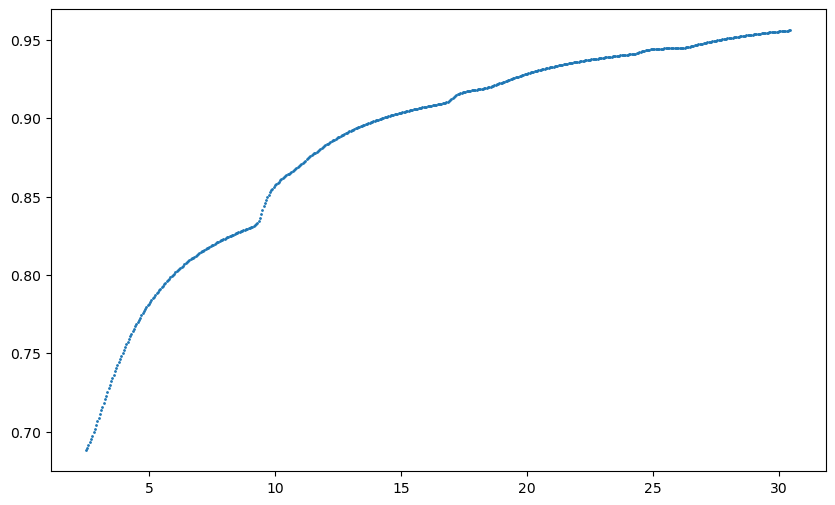

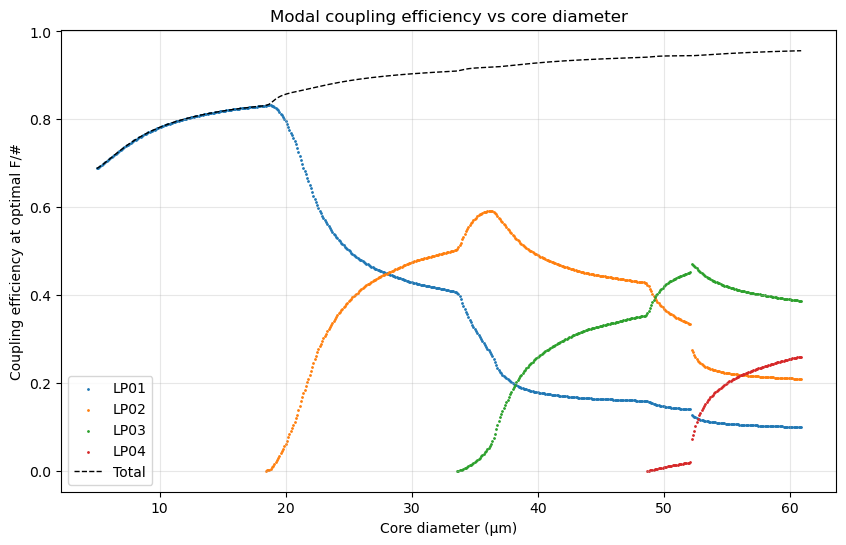

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(a_arr * 1e6, eta_total_arr, s=1)

# Core radius array
a_arr = np.array([row["a"] for row in data_few_sym_2d])          # in meters
a_um = a_arr * 1e6                                    # convert to microns

# Prepare arrays for LP01, LP02, LP03 efficiencies
eta_LP01 = np.full(len(data_few_sym_2d), np.nan)
eta_LP02 = np.full(len(data_few_sym_2d), np.nan)
eta_LP03 = np.full(len(data_few_sym_2d), np.nan)
eta_LP04 = np.full(len(data_few_sym_2d), np.nan)
eta_tot = np.array([row["eta_total_opt"] for row in data_few_sym_2d])

# Extract modal efficiencies from mode_results
for i, row in enumerate(data_few_sym_2d):
    for mode in row["mode_results"]:
        l = mode["l"]
        m = mode["m"]
        eta = mode["eta"]

        if l == 0 and m == 1:
            eta_LP01[i] = eta
        elif l == 0 and m == 2:
            eta_LP02[i] = eta
        elif l == 0 and m == 3:
            eta_LP03[i] = eta
        elif l == 0 and m == 4:
            eta_LP04[i] = eta

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(2* a_um, eta_LP01, s=1, label='LP01')
plt.scatter(2* a_um, eta_LP02, s=1, label='LP02')
plt.scatter(2* a_um, eta_LP03, s=1, label='LP03')
plt.scatter(2* a_um, eta_LP04, s=1, label='LP04')
plt.plot(2* a_um, eta_tot, linestyle='--', label='Total', color='black', linewidth=1)
plt.xlabel("Core diameter (µm)")
plt.ylabel("Coupling efficiency at optimal F/#")
plt.title("Modal coupling efficiency vs core diameter")
# plt.ylim(0.68, 0.9)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


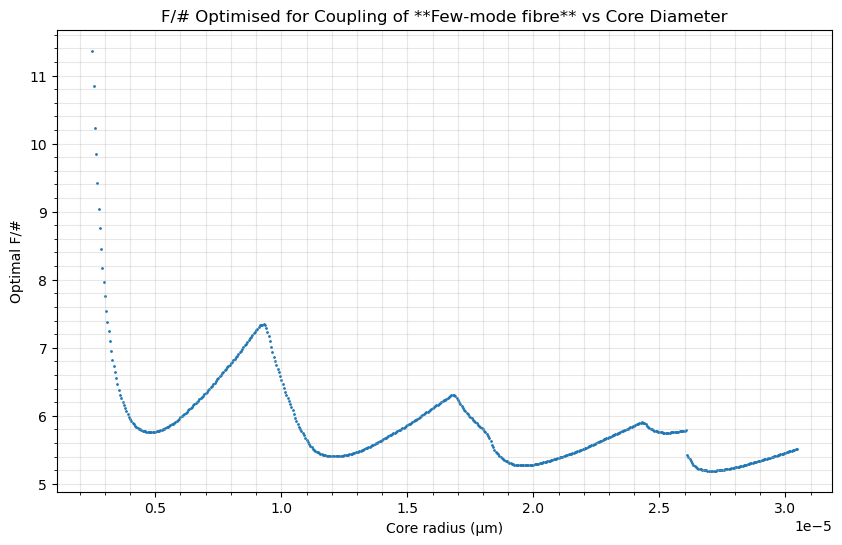

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(a_arr, F_opt_arr, s=1)
plt.xlabel("Core radius (µm)")
plt.ylabel("Optimal F/#")
plt.title("F/# Optimised for Coupling of **Few-mode fibre** vs Core Diameter")
# minorticks
plt.gca().minorticks_on()
plt.grid(True, which='both', alpha=0.3)
plt.show()


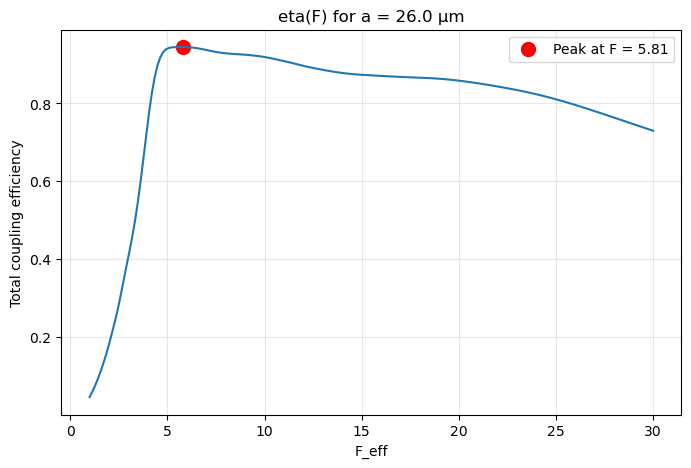

In [30]:
a_test = 26e-6

prepared_modes = prepare_modes_2d(
    x, y,
    a=a_test,
    NA=NA,
    lam0=lam0,
    az_sym=False,
    mode_case="few_mode"
)

F_grid = np.linspace(1, 30, 200)
eta_grid = []

for F in F_grid:
    eta, _ = total_eff_2d(
        prepared_modes,
        x, y, x_1d, y_1d,
        lam0=lam0,
        F_eff=F,
        alpha=0.0,
        decentre=None,
        E_S=1.0
    )
    eta_grid.append(eta)

eta_grid = np.array(eta_grid)
eta_peak_F = F_grid[np.argmax(eta_grid)]

plt.figure(figsize=(8, 5))
plt.plot(F_grid, eta_grid)
plt.scatter(eta_peak_F, np.max(eta_grid), color='red', s=100, label=f'Peak at F = {eta_peak_F:.2f}')
plt.xlabel("F_eff")
plt.ylabel("Total coupling efficiency")
plt.title(f"eta(F) for a = {a_test*1e6:.1f} µm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

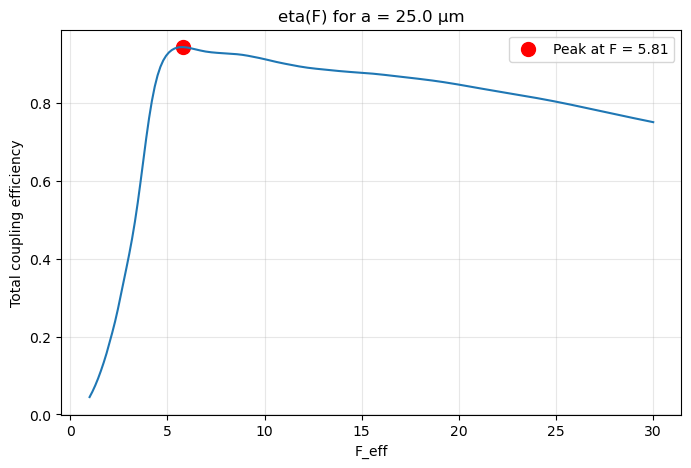

In [31]:
a_test = 25e-6

prepared_modes = prepare_modes_2d(
    x, y,
    a=a_test,
    NA=NA,
    lam0=lam0,
    az_sym=False,
    mode_case="few_mode"
)

F_grid = np.linspace(1, 30, 200)
eta_grid = []

for F in F_grid:
    eta, _ = total_eff_2d(
        prepared_modes,
        x, y, x_1d, y_1d,
        lam0=lam0,
        F_eff=F,
        alpha=0.0,
        decentre=None,
        E_S=1.0
    )
    eta_grid.append(eta)

eta_grid = np.array(eta_grid)
eta_peak_F = F_grid[np.argmax(eta_grid)]

plt.figure(figsize=(8, 5))
plt.plot(F_grid, eta_grid)
plt.scatter(eta_peak_F, np.max(eta_grid), color='red', s=100, label=f'Peak at F = {eta_peak_F:.2f}')
plt.xlabel("F_eff")
plt.ylabel("Total coupling efficiency")
plt.title(f"eta(F) for a = {a_test*1e6:.1f} µm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

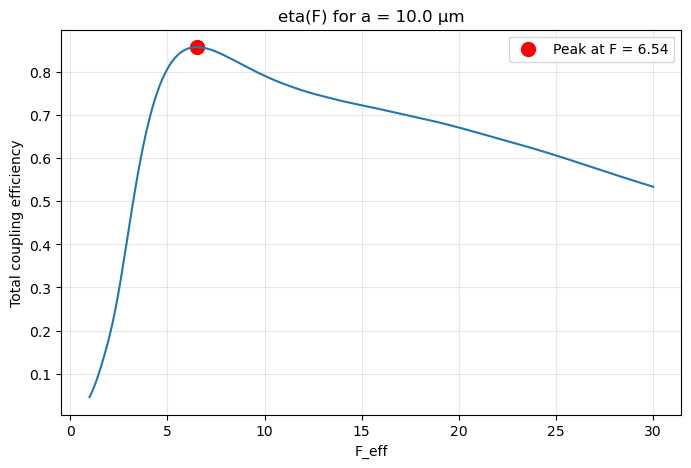

In [32]:
a_test = 10e-6

prepared_modes = prepare_modes_2d(
    x, y,
    a=a_test,
    NA=NA,
    lam0=lam0,
    az_sym=False,
    mode_case="few_mode"
)

F_grid = np.linspace(1, 30, 200)
eta_grid = []

for F in F_grid:
    eta, _ = total_eff_2d(
        prepared_modes,
        x, y, x_1d, y_1d,
        lam0=lam0,
        F_eff=F,
        alpha=0.0,
        decentre=None,
        E_S=1.0
    )
    eta_grid.append(eta)

eta_grid = np.array(eta_grid)
eta_peak_F = F_grid[np.argmax(eta_grid)]

plt.figure(figsize=(8, 5))
plt.plot(F_grid, eta_grid)
plt.scatter(eta_peak_F, np.max(eta_grid), color='red', s=100, label=f'Peak at F = {eta_peak_F:.2f}')
plt.xlabel("F_eff")
plt.ylabel("Total coupling efficiency")
plt.title(f"eta(F) for a = {a_test*1e6:.1f} µm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

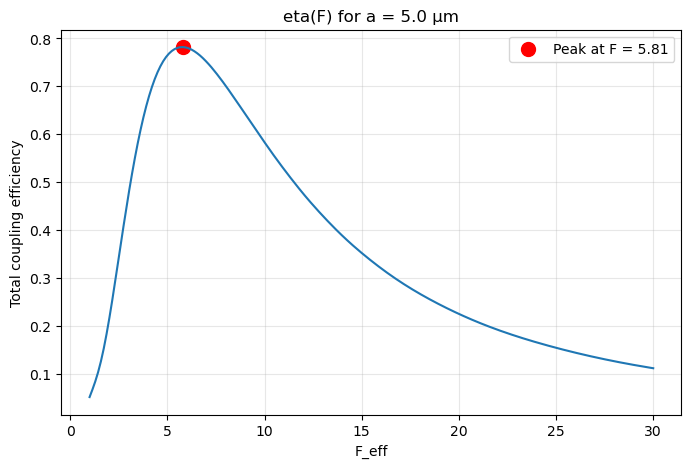

In [33]:
a_test = 5e-6

prepared_modes = prepare_modes_2d(
    x, y,
    a=a_test,
    NA=NA,
    lam0=lam0,
    az_sym=False,
    mode_case="few_mode"
)

F_grid = np.linspace(1, 30, 200)
eta_grid = []

for F in F_grid:
    eta, _ = total_eff_2d(
        prepared_modes,
        x, y, x_1d, y_1d,
        lam0=lam0,
        F_eff=F,
        alpha=0.0,
        decentre=None,
        E_S=1.0
    )
    eta_grid.append(eta)

eta_grid = np.array(eta_grid)
eta_peak_F = F_grid[np.argmax(eta_grid)]

plt.figure(figsize=(8, 5))
plt.plot(F_grid, eta_grid)
plt.scatter(eta_peak_F, np.max(eta_grid), color='red', s=100, label=f'Peak at F = {eta_peak_F:.2f}')
plt.xlabel("F_eff")
plt.ylabel("Total coupling efficiency")
plt.title(f"eta(F) for a = {a_test*1e6:.1f} µm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

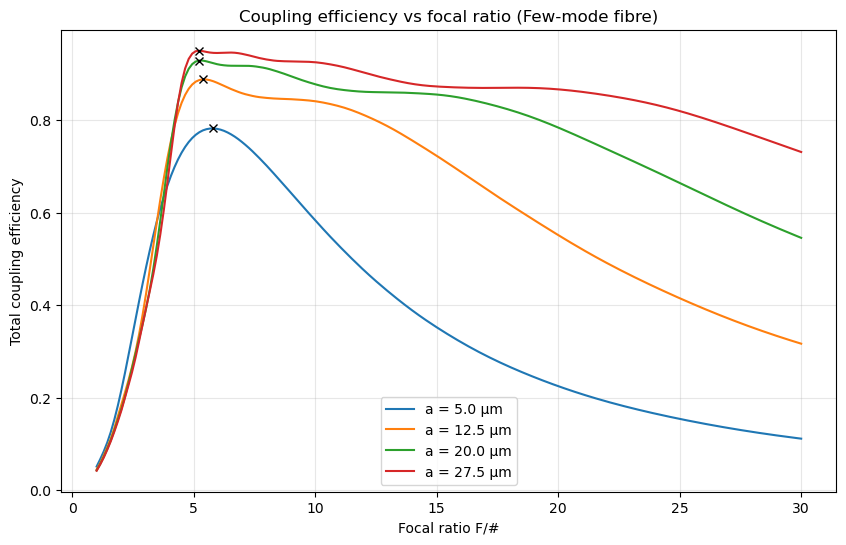

In [73]:
target_radii_um = [5, 12.5, 20, 27.5]

plt.figure(figsize=(10, 6))

for target_um in target_radii_um:
    a_target = target_um * 1e-6

    # Use the closest radius available in your sampled array
    idx = np.argmin(np.abs(a_arr - a_target))
    a_use = a_arr[idx]

    prepared_modes = prepare_modes_2d(
        x, y,
        a=a_use,
        NA=NA,
        lam0=lam0,
        az_sym=False,
        mode_case="few_mode"
    )

    F_grid = np.linspace(1, 30, 200)
    eta_grid = []

    for F in F_grid:
        eta, _ = total_eff_2d(
            prepared_modes,
            x, y, x_1d, y_1d,
            lam0=lam0,
            F_eff=F,
            alpha=0.0,
            decentre=None,
            E_S=1.0
        )
        eta_grid.append(eta)

    eta_grid = np.array(eta_grid)
    eta_peak_F = F_grid[np.argmax(eta_grid)]

    plt.plot(F_grid, eta_grid, label=f"a = {a_use*1e6:.1f} µm")
    plt.plot(eta_peak_F, np.max(eta_grid), "x", color="k")

plt.xlabel("Focal ratio F/#")
plt.ylabel("Total coupling efficiency")
plt.title("Coupling efficiency vs focal ratio (Few-mode fibre)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
fminbound?

Signature:
fminbound(
    func,
    x1,
    x2,
    args=(),
    xtol=1e-05,
    maxfun=500,
    full_output=0,
    disp=1,
)
Docstring:
Bounded minimization for scalar functions.

Parameters
----------
func : callable f(x,*args)
    Objective function to be minimized (must accept and return scalars).
x1, x2 : float or array scalar
    Finite optimization bounds.
args : tuple, optional
    Extra arguments passed to function.
xtol : float, optional
    The convergence tolerance.
maxfun : int, optional
    Maximum number of function evaluations allowed.
full_output : bool, optional
    If True, return optional outputs.
disp: int, optional
    If non-zero, print messages.

    ``0`` : no message printing.

    ``1`` : non-convergence notification messages only.

    ``2`` : print a message on convergence too.

    ``3`` : print iteration results.

Returns
-------
xopt : ndarray
    Parameters (over given interval) which minimize the
    objective function.
fval : number
    (Optional outp

# Background

In [35]:
def eta_background_from_psf_weights(decentre_array, eta_psf_array): 
    """
    Calculate the background coupling efficiency (eta_background) from the PSF coupling efficiency 
    (eta_psf(r)) as a function of decentre r. 

    The background coupling efficiency is calculated as the weighted average of the PSF coupling 
    efficiency over the image field, where the weights are given by the intensity distribution 
    of the image field (I_ext(r/f)). 

    eta_ext(background) = ∫ eta_psf(r) * I_ext(r/f) dA / ∫ I_ext(r/f) dA, where A is the area of the image field.

    For the background, the image field would not be optimised via focal ratio, and the image field 
    of a decentred psf here would use the optimal F of the centred case. 

    Parameters: 
    decentre_array: 1D array of decentre values (r) in meters
    eta_psf_array: 1D array of PSF coupling efficiency values corresponding to each decentre value in decentre_array


    """
    # numerator = ∫ eta_psf(r) * I_ext(r/f) dA, where A=pi * r^2, so dA = 2 * pi * r dr  
    # I_ext(r^arrow) = I_0 for a completely uniform field, where I_0 is a constant that cancels out in the ratio, so we can ignore it in the calculation. 
    I_0=1.0
    numerator = integrate.simpson(eta_psf_array * I_0 * 2 * np.pi * decentre_array, x=decentre_array)
    # denominator = ∫ I_ext(r/f) dA, where A=pi * r^2, so dA = 2 * pi * r dr
    denominator = integrate.simpson(I_0 * 2 * np.pi * decentre_array, x=decentre_array)

    eta_background = numerator / denominator

    return eta_background



In [36]:

def eta_psf_vs_decentre_position_2d(
        prepared_modes, 
        x, y, x_1d, y_1d, 
        lam0, F_eff, alpha, 
        decentre_array, 
        E_S = 1.0, 
        direction_angle = 0.0
):
    """
    Calculate the coupling efficiency of a point source  as a function to its decentre relative 
    to the fibre. 

    Parameters: 
    prepared_modes: the pre-computed fibre modes containing eigenfield information for ONE core radius

    decentre_array: array of image positions relative to the fibre centre

    direction_angle: the angle of offset direction in the x-y grid plane
    Assuming angle is zero for a circularly symmetric aperature
    """

    eta_psf = [] # prepare array of eta_psf for each decentre coordinate
    mode_results_all = [] # not required but returns the fields of eigenmodes

    for r in decentre_array: # r is distance to centre
        dx = r * np.cos(direction_angle) # cos(0)=1, we are varying in the x direction
        dy = r * np.sin(direction_angle) # sin(0)=0 

        eta_total, mode_results = total_eff_2d(
            prepared_modes, 
            x, y, x_1d, y_1d, 
            lam0=lam0, 
            F_eff=F_eff, 
            alpha=alpha, 
            decentre=(dx, dy),
            E_S=E_S
        )

        eta_psf.append(eta_total)
        mode_results_all.append(mode_results)

    eta_psf = np.array(eta_psf)

    return eta_psf, mode_results_all


In [37]:
def background_efficiency_at_one_radius_2d(
        a,
        x, y, x_1d, y_1d, 
        NA, lam0, 
        alpha=0.0, 
        az_sym=True, 
        mode_case="smf", 
        decentre_max=None, 
        n_decentre=50, E_S=1.0, 
        n_F_grid=60, 
        F_opt_input=None
):
    """
    For one fibre core radius a: 
        1. Prepare fibre modes
        2. Optimise F_eff for centred point source
        3. Calculate eta_psf(d)
        4. Integrate eta_psf(d) to get flat-background efficiency

    Parameters: 
    decentre_max: the maximum decentre radius, set to None, but equals to the cladding radius
    n_decentre: the number of decentre points to consider
    E_S: the electric field amplitude of the point source
    n_F_grid: the number of grid points for the F_eff calculation
    F_opt_input: 

    """

    V = 2 * np.pi * a * NA / lam0

    prepared_modes = prepare_modes_2d(
        x, y, 
        a=a, 
        NA=NA, 
        lam0=lam0,
        az_sym=az_sym, 
        mode_case=mode_case
    )

    # Optimise F for centred point source only
    if F_opt_input is None: 
        F_opt, eta_centre, mode_results_centred, E_image_opt, I_image_opt = (
            maximize_coupling_fix_a_prepared(
                prepared_modes,
                x=x, y=y, x_1d=x_1d, y_1d=y_1d,
                lam0=lam0,
                NA=NA,
                alpha=alpha,
                decentre=None,
                E_S=E_S,
                n_F_grid=n_F_grid
            )
        )
    
    else: 
        F_opt = F_opt_input

        eta_centre, mode_results_centred = total_eff_2d(
            prepared_modes,
            x=x, y=y, x_1d=x_1d, y_1d=y_1d,
            lam0=lam0,
            F_eff=F_opt,
            alpha=alpha,
            decentre=None,
            E_S=E_S
        )

        E_image_opt, I_image_opt = diffraction_limited_E_field_at_fibre_2d(
            x, y,
            lam0=lam0,
            F_eff=F_opt,
            alpha=alpha,
            E_S=E_S,
            decentre=None
        )

    # Choose decentre_max to be the cladding radius if not specified
    if decentre_max is None: 
        r_max = 125e-6 # in meters, this is the maximum radius of the grid we prepared for the field calculations, so we can't go beyond this
        decentre_max = r_max # cladding radius 

    decentre_array = np.linspace(0, decentre_max, n_decentre)

    # Calculate eta_psf(d) for the range of decentre values
    eta_psf,  mode_results_decentre = eta_psf_vs_decentre_position_2d(
        prepared_modes, 
        x, y, x_1d, y_1d,
        lam0=lam0, F_eff=F_opt, alpha=alpha,
        decentre_array=decentre_array,
        E_S=E_S
    )

    # Integrate over the flat background, assume I_background is unitorm so I_ext(r/f) = I_0, 
    # where I_0 is a constant that cancels out in the ratio, so we can ignore it in the calculation.
    eta_background = eta_background_from_psf_weights(decentre_array, eta_psf)
    
    return {
        "a": a,
        "V": V,
        "F_opt": F_opt,
        "eta_centre": eta_centre,
        "eta_background": eta_background,
        "decentre_array": decentre_array,
        "eta_psf": eta_psf,
        "mode_results_centred": mode_results_centred,
        "mode_results_decentre": mode_results_decentre,
        "E_image_opt": E_image_opt,
        "I_image_opt": I_image_opt
    }


In [38]:
def background_efficiency_vs_core_radius_2d(
        core_radius_array, 
        x, y, x_1d, y_1d,
        NA, lam0,
        alpha=0.0,
        az_sym=True,
        mode_case="smf",
        decentre_max=None,
        n_decentre=50, 
        E_S=1.0, 
        n_F_grid=60,
        n_jobs=1, 
        F_opt_array = None
):
    """Loop over core radius and calculate: 
        - centred point source efficiency at optimal F
        - background efficiency by the weighted average of a number of decentred point source efficiencies

    Parameters:
    core_radius_array: array of core radius values to process
    x, y, x_1d, y_1d: grid points for the field calculations
    NA: numerical aperture
    lam0: wavelength
    alpha: polarization angle
    az_sym: whether to use azimuthal symmetry
    mode_case: case for mode calculation
    decentre_max: maximum decentre radius
    n_decentre: number of decentre points
    E_S: electric field amplitude of the point source
    n_F_grid: number of grid points for F_eff calculation
    n_jobs: number of parallel workers. Use 1 for serial, >1 for parallel.

    Return: 
    results: list of dictionaries containing the background efficiency and other related 
    information for each core radius in the range of core_radius_array
    """
    # Count how many individual core radiuses are computed
    n_total = len(core_radius_array)
    if F_opt_array is not None and len(F_opt_array) == n_total:
        F_opt_array = np.asarray(F_opt_array)

    def run_one_radius(i, a):
        if F_opt_array is None: 
            F_opt_input = None 
        else: 
            F_opt_input = F_opt_array[i]

        row = background_efficiency_at_one_radius_2d(
            a=a, 
            x=x, y=y, x_1d=x_1d, y_1d=y_1d,
            NA=NA, 
            lam0=lam0,
            alpha=alpha,
            az_sym=az_sym, 
            mode_case=mode_case,
            decentre_max=decentre_max, 
            n_decentre=n_decentre, 
            E_S=E_S,
            n_F_grid=n_F_grid, 
            F_opt_input=F_opt_input # remember to pass the F_opt_input for each radius if provided
        )
        return row
    



    if n_jobs == 1:
        results = []

        checkpoints = {
            max(1, int(np.ceil(n_total * p / 10))) 
            for p in range(1, 11)
        }

        for i, a in enumerate(core_radius_array, start=0):
            results.append(run_one_radius(i,a))

            step=i + 1 # step is the number of core radiuses we have processed so far, starting from 1

            if i in checkpoints:
                percent = int(round(100 * step / n_total))
                print(f"{percent}% complete ({step}/{n_total})")

    else:
        results = Parallel(n_jobs=n_jobs, verbose=10)(
            delayed(run_one_radius)(i,a)
            for i, a in enumerate(core_radius_array, start=0)
        )

    return results

In [39]:
# core_radius_test_small = np.linspace(1.2e-6, 20e-6, 80)
results_bg_mmf = background_efficiency_vs_core_radius_2d(
    core_radius_array=core_radius_range_test,
    x=x,
    y=y,
    x_1d=x_1d,
    y_1d=y_1d,
    NA=NA,
    lam0=lam0,
    alpha=0.0,
    az_sym=False,
    mode_case="few_mode",
    decentre_max=None,
    n_decentre=40,
    E_S=1.0,
    n_F_grid=60, 
    n_jobs=4, 
    F_opt_array = F_opt_arr
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    4.2s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    6.3s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   12.3s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   14.5s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   20.7s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   25.0s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:   32.0s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:   39.7s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:   57.6s
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:  1.5min
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:  1.8min
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed:  2.2min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:  2.7min
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed:  3.3min
[Parallel(

In [40]:
a_arr = np.array([row["a"] for row in results_bg_mmf])
F_opt_arr = np.array([row["F_opt"] for row in results_bg_mmf])
eta_centre_arr = np.array([row["eta_centre"] for row in results_bg_mmf])
eta_bg_arr = np.array([row["eta_background"] for row in results_bg_mmf])

In [41]:
# idx = 500   # choose a larger core radius index

# a_test = results_bg_mmf[idx]["a"]
# mode_results = results_bg_mmf[idx]["mode_results_centred"]

# print(f"a = {a_test*1e6:.2f} µm")
# print("Number of mode branches:", len(mode_results))
# print("Modes:")

# for mode in mode_results:
#     print(mode["l"], mode["m"], mode.get("angular", None), f"eta={mode['eta']:.4f}")

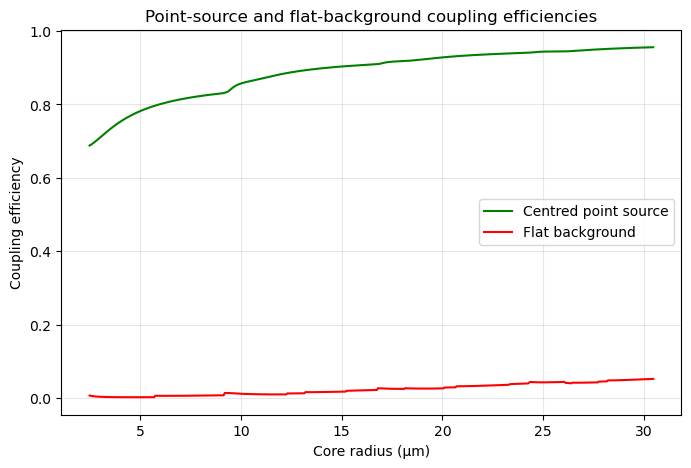

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(a_arr * 1e6, eta_centre_arr, label="Centred point source", color='green')
plt.plot(a_arr * 1e6, eta_bg_arr, label="Flat background", color='red')
plt.xlabel("Core radius (µm)")
plt.ylabel("Coupling efficiency")
plt.title("Point-source and flat-background coupling efficiencies")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
eta_ratio_max_index = np.argmax(eta_centre_arr / np.sqrt(eta_bg_arr))
print(f"Maximum eta_centre / sqrt(eta_bg) ratio of {eta_centre_arr[eta_ratio_max_index] / np.sqrt(eta_bg_arr[eta_ratio_max_index]):.3f} at a = {a_arr[eta_ratio_max_index]*1e6:.2f} µm")

Maximum eta_centre / sqrt(eta_bg) ratio of 18.597 at a = 5.15 µm


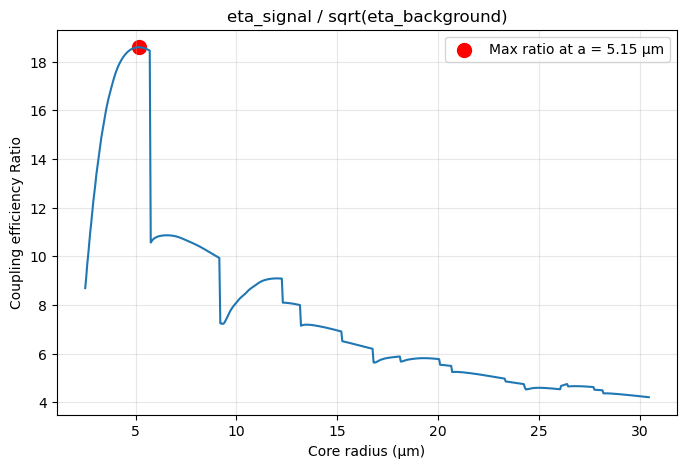

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(a_arr * 1e6, eta_centre_arr / np.sqrt(eta_bg_arr))
plt.scatter(a_arr[eta_ratio_max_index] * 1e6, eta_centre_arr[eta_ratio_max_index] / np.sqrt(eta_bg_arr[eta_ratio_max_index]), color='red', s=100, label=f'Max ratio at a = {a_arr[eta_ratio_max_index]*1e6:.2f} µm')
plt.xlabel("Core radius (µm)")
plt.ylabel("Coupling efficiency Ratio")
plt.title("eta_signal / sqrt(eta_background)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_91763/1052715621.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


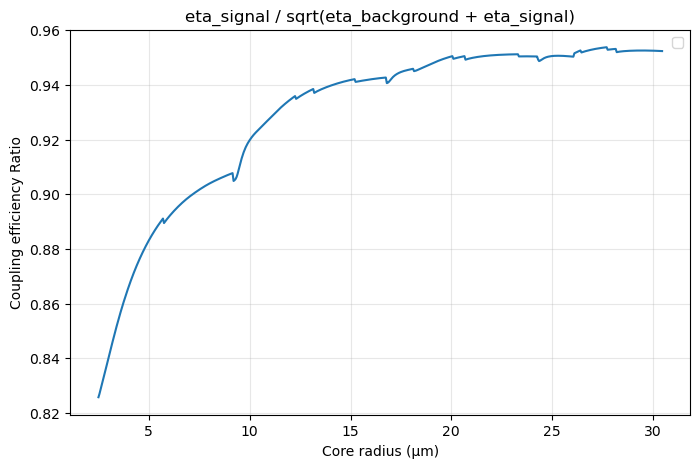

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(a_arr * 1e6, eta_centre_arr / np.sqrt(eta_centre_arr + eta_bg_arr))
plt.xlabel("Core radius (µm)")
plt.ylabel("Coupling efficiency Ratio")
plt.title("eta_signal / sqrt(eta_background + eta_signal)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

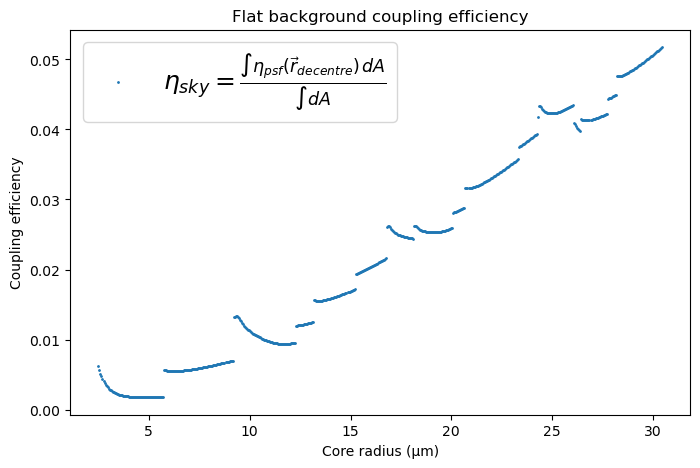

In [46]:
plt.figure(figsize=(8, 5))
plt.scatter(a_arr * 1e6, eta_bg_arr, s=1, label=r'$\eta_{sky}=\frac{\int \eta_{psf}(\vec{r}_{decentre})\,dA}{\int dA}$')
plt.xlabel("Core radius (µm)")
plt.title("Flat background coupling efficiency")
plt.ylabel("Coupling efficiency")
plt.legend(fontsize=18)

In [47]:
np.min(eta_bg_arr)

np.float64(0.0017565388665831765)

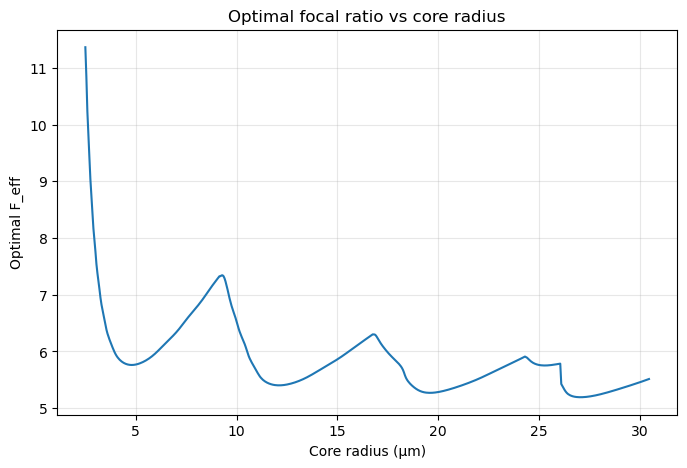

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(a_arr * 1e6, F_opt_arr)
plt.xlabel("Core radius (µm)")
plt.ylabel("Optimal F_eff")
plt.title("Optimal focal ratio vs core radius")
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

# Extract result around 5 micron core radius
result_5um = results_bg_mmf[50]

a_5um = result_5um["a"]
decentre_array = result_5um["decentre_array"]
eta_psf_5um = result_5um["eta_psf"]

print(f"Core radius = {a_5um*1e6:.3f} micron")

# Build interpolation function eta_psf(d)
eta_interp = interp1d(
    decentre_array,
    eta_psf_5um,
    bounds_error=False,
    fill_value=0.0
)

# Make x-y decentre coordinate grid
d_max = decentre_array[-1]

n_map = 300
x_dec_1d = np.linspace(-d_max, d_max, n_map)
y_dec_1d = np.linspace(-d_max, d_max, n_map)

X_dec, Y_dec = np.meshgrid(x_dec_1d, y_dec_1d)

# Radial decentre distance
D_dec = np.sqrt(X_dec**2 + Y_dec**2)

# Convert radial eta_psf(d) into 2D eta map
eta_map_5micron_2d = eta_interp(D_dec)

# Optional: mask outside circular averaging region
eta_map_5micron_2d[D_dec > d_max] = np.nan

Core radius = 5.000 micron


In [50]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

# Extract result around 10 micron core radius
result_10um = results_bg_mmf[150]

a_10um = result_10um["a"]
decentre_array = result_10um["decentre_array"]
eta_psf_10um = result_10um["eta_psf"]

print(f"Core radius = {a_10um*1e6:.3f} micron")

# Build interpolation function eta_psf(d)
eta_interp = interp1d(
    decentre_array,
    eta_psf_10um,
    bounds_error=False,
    fill_value=0.0
)

# Make x-y decentre coordinate grid
d_max = decentre_array[-1]

n_map = 300
x_dec_1d = np.linspace(-d_max, d_max, n_map)
y_dec_1d = np.linspace(-d_max, d_max, n_map)

X_dec, Y_dec = np.meshgrid(x_dec_1d, y_dec_1d)

# Radial decentre distance
D_dec = np.sqrt(X_dec**2 + Y_dec**2)

# Convert radial eta_psf(d) into 2D eta map
eta_map_10micron_2d = eta_interp(D_dec)

# Optional: mask outside circular averaging region
eta_map_10micron_2d[D_dec > d_max] = np.nan

Core radius = 10.000 micron


In [51]:
target_radii_um = [5, 12.5, 20, 27.5] # in microns
target_radii_m = np.array(target_radii_um) * 1e-6 # convert to meters

result_fixed_a_list = []
eta_2d_map_list = []

a_array = np.array([row["a"] for row in results_bg_mmf])

for target_a in target_radii_m:
    # Find the index of the closest core radius in the results
    idx = np.argmin(np.abs(a_array - target_a))
    result_fixed_a = results_bg_mmf[idx]

    # Extract the relevant data for this core radius
    a_at_target = result_fixed_a["a"]
    decentre_array = result_fixed_a["decentre_array"]
    eta_psf_array = result_fixed_a["eta_psf"]

    print(f"Target radius = {target_a*1e6:.1f} micron")
    print(f"Closest stored radius = {a_at_target*1e6:.3f} micron")

    # Build interpolation function eta_psf(d), which we will use to convert the radial eta_psf(d) 
    # into a 2D eta map
    eta_interp = interp1d(
        decentre_array,
        eta_psf_array,
        bounds_error=False,
        fill_value=0.0
    )

    # Make x-y decentre coordinate grid
    d_max = np.max(decentre_array)

    n_map = 300 # number of points in the x and y directions for the 2D map
    x_dec_1d = np.linspace(-d_max, d_max, n_map)
    y_dec_1d = np.linspace(-d_max, d_max, n_map)

    X_dec, Y_dec = np.meshgrid(x_dec_1d, y_dec_1d)

    # Radial decentre distance
    D_dec = np.sqrt(X_dec**2 + Y_dec**2)

    # Convert radial eta_psf(d) into 2D eta map
    eta_map_2d = eta_interp(D_dec)

    # Mask outside circular averaging region
    eta_map_2d = eta_interp(D_dec) # convert radial eta_psf(d) into 2D eta map, using D_dec the radial decentre distance
    eta_map_2d[D_dec > d_max] = np.nan # mask outside circular

    result_fixed_a_list.append(result_fixed_a)
    eta_2d_map_list.append(eta_map_2d)



Target radius = 5.0 micron
Closest stored radius = 5.000 micron
Target radius = 12.5 micron
Closest stored radius = 12.500 micron
Target radius = 20.0 micron
Closest stored radius = 20.000 micron
Target radius = 27.5 micron
Closest stored radius = 27.500 micron


In [52]:
a_5um = result_fixed_a_list[0]["a"]
decentre_array_5um = result_fixed_a_list[0]["decentre_array"]
eta_psf_5um = result_fixed_a_list[0]["eta_psf"]

a_12p5um = result_fixed_a_list[1]["a"]
decentre_array_12p5um = result_fixed_a_list[1]["decentre_array"]
eta_psf_12p5um = result_fixed_a_list[1]["eta_psf"]

a_20um = result_fixed_a_list[2]["a"]
decentre_array_20um = result_fixed_a_list[2]["decentre_array"]
eta_psf_20um = result_fixed_a_list[2]["eta_psf"]

a_27p5um = result_fixed_a_list[3]["a"]
decentre_array_27p5um = result_fixed_a_list[3]["decentre_array"]
eta_psf_27p5um = result_fixed_a_list[3]["eta_psf"]

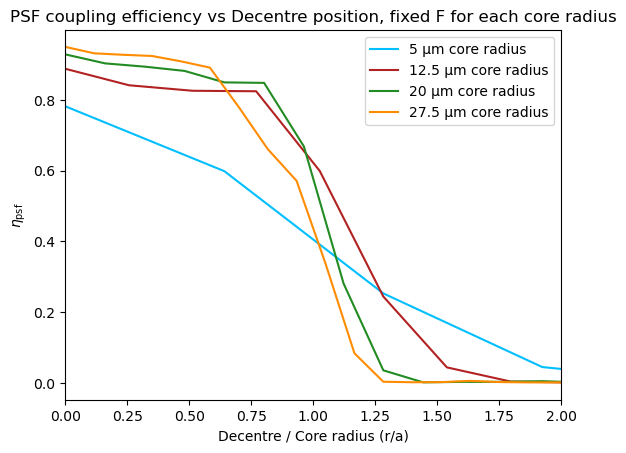

In [53]:
plt.plot(decentre_array / a_5um, eta_psf_5um, color='deepskyblue', label='5 µm core radius')
plt.plot(decentre_array / a_12p5um, eta_psf_12p5um, color='firebrick', label='12.5 µm core radius')
plt.plot(decentre_array / a_20um, eta_psf_20um, color='forestgreen', label='20 µm core radius')
plt.plot(decentre_array / a_27p5um, eta_psf_27p5um, color='darkorange', label='27.5 µm core radius')
plt.xlabel("Decentre / Core radius (r/a)")
plt.ylabel(r"$\eta_{\rm psf}$")
plt.title(f"PSF coupling efficiency vs Decentre position, fixed F for each core radius")
plt.xlim(0, 2)
plt.legend()
plt.show()

In [54]:
decentre_array * 1e6

array([  0.        ,   3.20512821,   6.41025641,   9.61538462,
        12.82051282,  16.02564103,  19.23076923,  22.43589744,
        25.64102564,  28.84615385,  32.05128205,  35.25641026,
        38.46153846,  41.66666667,  44.87179487,  48.07692308,
        51.28205128,  54.48717949,  57.69230769,  60.8974359 ,
        64.1025641 ,  67.30769231,  70.51282051,  73.71794872,
        76.92307692,  80.12820513,  83.33333333,  86.53846154,
        89.74358974,  92.94871795,  96.15384615,  99.35897436,
       102.56410256, 105.76923077, 108.97435897, 112.17948718,
       115.38461538, 118.58974359, 121.79487179, 125.        ])

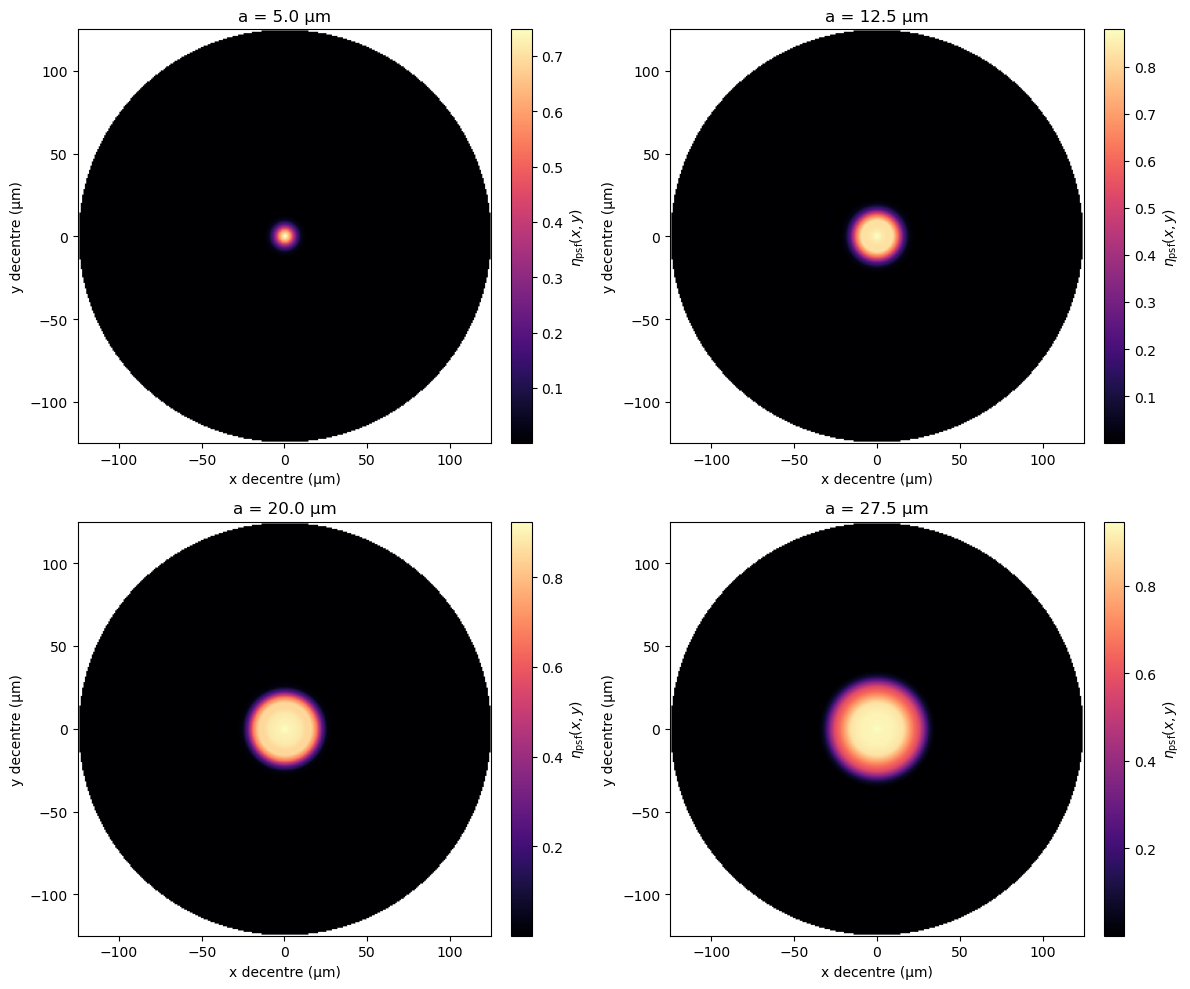

In [55]:
plt.figure(figsize=(12,10))

extent = [
    x_dec_1d[0]*1e6, x_dec_1d[-1]*1e6,
    y_dec_1d[0]*1e6, y_dec_1d[-1]*1e6
]

plt.subplot(2, 2, 1)
im1 = plt.imshow(eta_2d_map_list[0], extent=extent, origin="lower", aspect="equal", cmap='magma')
plt.title(f"a = {a_5um*1e6:.1f} µm")
plt.xlabel("x decentre (µm)")
plt.ylabel("y decentre (µm)")
plt.colorbar(label=r"$\eta_{\rm psf}(x,y)$", fraction=0.046, pad=0.04, cmap='magma')


plt.subplot(2, 2, 2)
im2 = plt.imshow(eta_2d_map_list[1], extent=extent, origin="lower", aspect="equal", cmap='magma')
plt.title(f"a = {a_12p5um*1e6:.1f} µm")
plt.xlabel("x decentre (µm)")
plt.ylabel("y decentre (µm)")
plt.colorbar(label=r"$\eta_{\rm psf}(x,y)$", fraction=0.046, pad=0.04, cmap='magma')

plt.subplot(2, 2, 3)
im3 = plt.imshow(eta_2d_map_list[2], extent=extent, origin="lower", aspect="equal", cmap='magma')
plt.title(f"a = {a_20um*1e6:.1f} µm")
plt.xlabel("x decentre (µm)")
plt.ylabel("y decentre (µm)")
plt.colorbar(label=r"$\eta_{\rm psf}(x,y)$", fraction=0.046, pad=0.04, cmap='magma')

plt.subplot(2, 2, 4)
im4 = plt.imshow(eta_2d_map_list[3], extent=extent, origin="lower", aspect="equal", cmap='magma')
plt.title(f"a = {a_27p5um*1e6:.1f} µm")
plt.xlabel("x decentre (µm)")
plt.ylabel("y decentre (µm)")
plt.colorbar(label=r"$\eta_{\rm psf}(x,y)$", fraction=0.046, pad=0.04, cmap='magma')

plt.tight_layout()
plt.show()

# Relative Signal-to-noise ratio

In [56]:
from scipy import integrate
import numpy as np
import matplotlib.pyplot as plt

F_focus = 49.9
D_M1 = 8.0
alpha = 0.0

I_flat = 1.0

rad_to_arcsec = (180 / np.pi) * 3600
plate_scale_coude = rad_to_arcsec / (F_focus * D_M1)  # arcsec / metre at telescope focal plane

# Extract arrays
core_radius_arr = np.array([row["a"] for row in results_bg_mmf])
F_opt_arr = np.array([row["F_opt"] for row in results_bg_mmf])
eta_background_arr = np.array([row["eta_background"] for row in results_bg_mmf])

# This should come from the signal/centred optimisation result
eta_total_arr = np.array([row["eta_total_opt"] for row in data_few_sym_2d])
# If your key is different, use:
# eta_total_arr = np.array([row["eta_centre"] for row in results_bg_mmf])

signal_incident_array = np.zeros_like(core_radius_arr)
signal_coupled_array = np.zeros_like(core_radius_arr)
FOV_array = np.zeros_like(core_radius_arr)
background_incident_array = np.zeros_like(core_radius_arr)
background_coupled_array = np.zeros_like(core_radius_arr)
snr_array = np.zeros_like(core_radius_arr)
Magnification_array = np.zeros_like(core_radius_arr)

for i, a in enumerate(core_radius_arr):

    I_image = data_few_sym_2d[i]["I_image_opt"]  # should be 2D

    F_opt = F_opt_arr[i]

    Magnification = F_opt / F_focus
    Magnification_array[i] = Magnification

    plate_scale_demag = plate_scale_coude / Magnification

    # Geometric fibre field of view in arcsec
    FOV = plate_scale_demag * 2 * a
    FOV_array[i] = FOV

    # 2D incident point-source image power
    # signal_x = integrate.simpson(I_image, x=x_1d, axis=1)
    # Signal_incident = integrate.simpson(signal_x, x=y_1d)

    # constant signal
    Signal0 = 1.0
    Signal_incident = Signal0

    # Coupled point-source signal
    Signal_coupled = Signal_incident * eta_total_arr[i]

    # Incident flat background over sky/FOV area
    Background_incident = I_flat * np.pi * (FOV / 2)**2

    # Coupled background
    Background_coupled = Background_incident * eta_background_arr[i]

    signal_incident_array[i] = Signal_incident
    signal_coupled_array[i] = Signal_coupled
    background_incident_array[i] = Background_incident
    background_coupled_array[i] = Background_coupled

    snr_array[i] = Signal_coupled / np.sqrt(Background_coupled)
    # snr_array[i] = eta_total_arr[i] / np.sqrt(eta_background_arr[i] * background_incident_array[i])

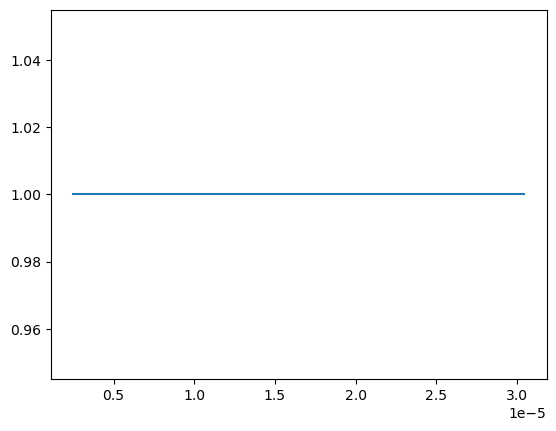

In [57]:
plt.plot(core_radius_arr, signal_incident_array)

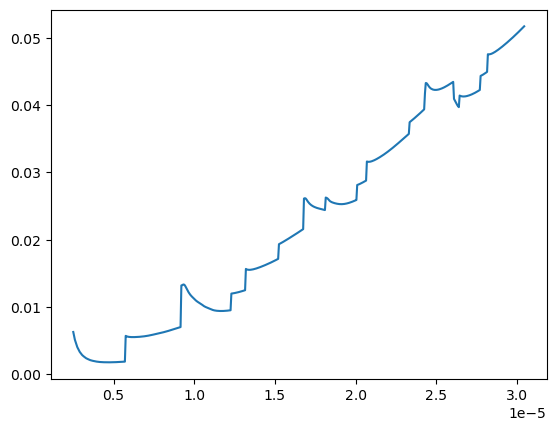

In [58]:
plt.plot(core_radius_arr, eta_background_arr)

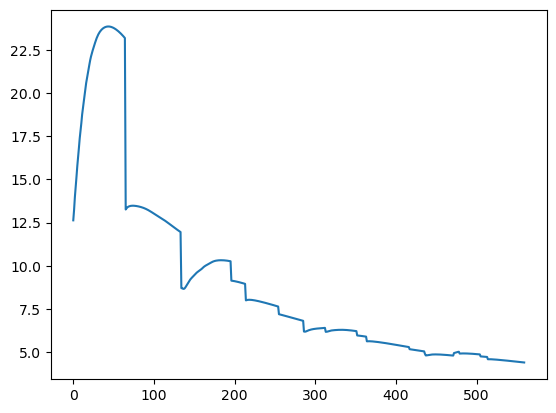

In [59]:
plt.plot(1 / np.sqrt(eta_background_arr))

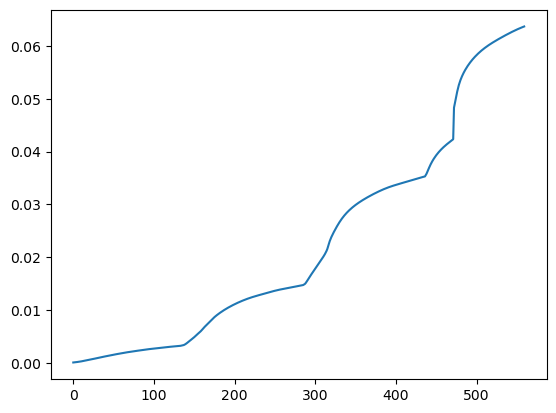

In [60]:
plt.plot(background_incident_array)

Text(0.5, 1.0, '1/sqrt(Background incident) vs Core radius')

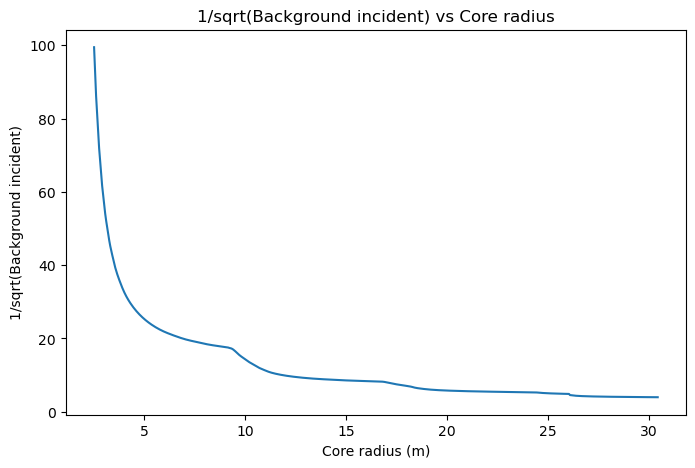

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, 1 / np.sqrt(background_incident_array))
plt.xlabel("Core radius (m)")
plt.ylabel("1/sqrt(Background incident)")
plt.title("1/sqrt(Background incident) vs Core radius")

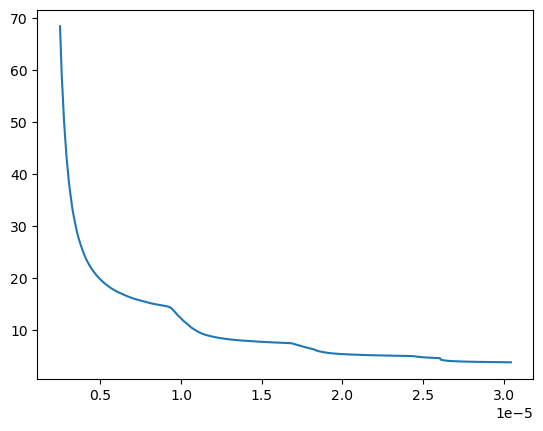

In [62]:
plt.plot(core_radius_arr, eta_total_arr / np.sqrt(background_incident_array))

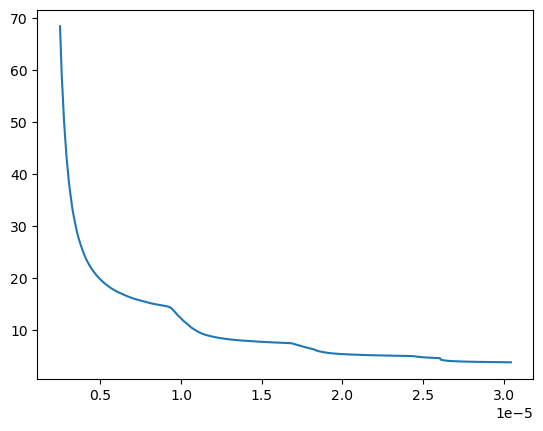

In [63]:
plt.plot(core_radius_arr, eta_total_arr / np.sqrt(background_incident_array))

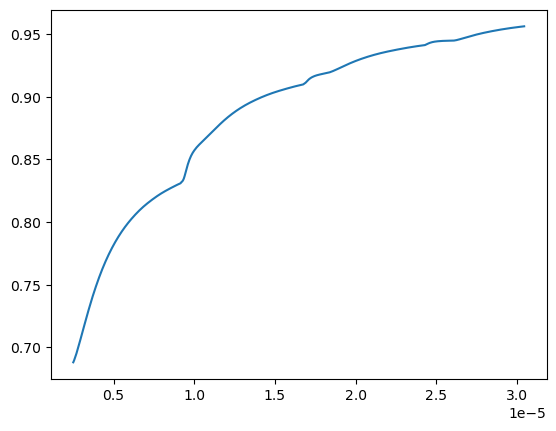

In [64]:
plt.plot(core_radius_arr, eta_total_arr)

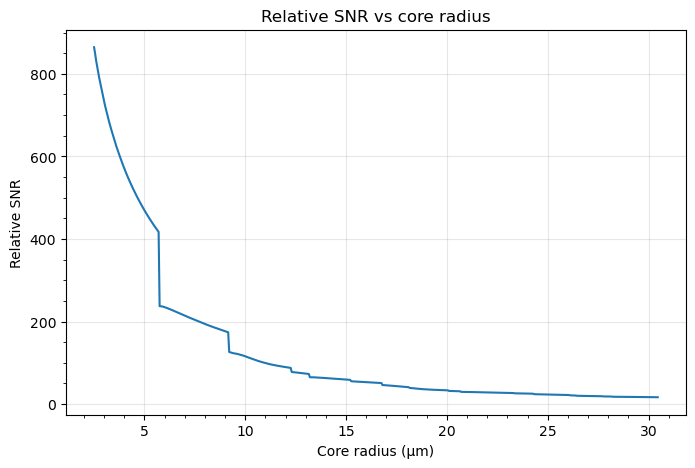

In [65]:
snr_rel = snr_array 

plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, snr_rel)
plt.xlabel("Core radius (µm)")
plt.ylabel("Relative SNR")
plt.title("Relative SNR vs core radius")
# add minor ticks
plt.gca().minorticks_on()
plt.grid(True, alpha=0.3)
plt.show()

Text(0.5, 1.0, 'FOV vs Core radius')

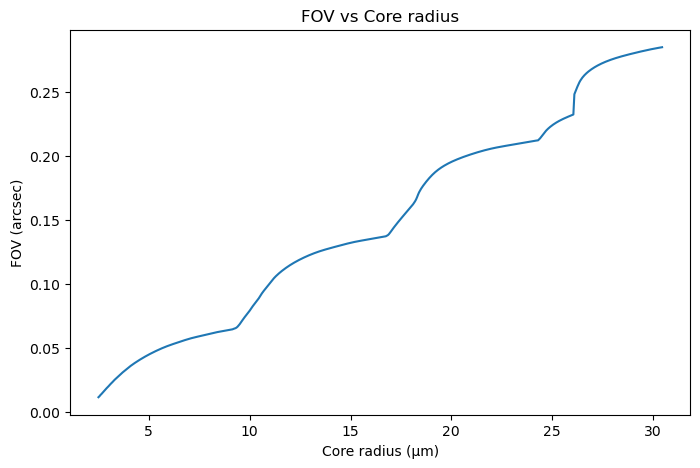

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, FOV_array)
plt.xlabel("Core radius (μm)")
plt.ylabel("FOV (arcsec)")
plt.title("FOV vs Core radius")

/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_91763/310279767.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


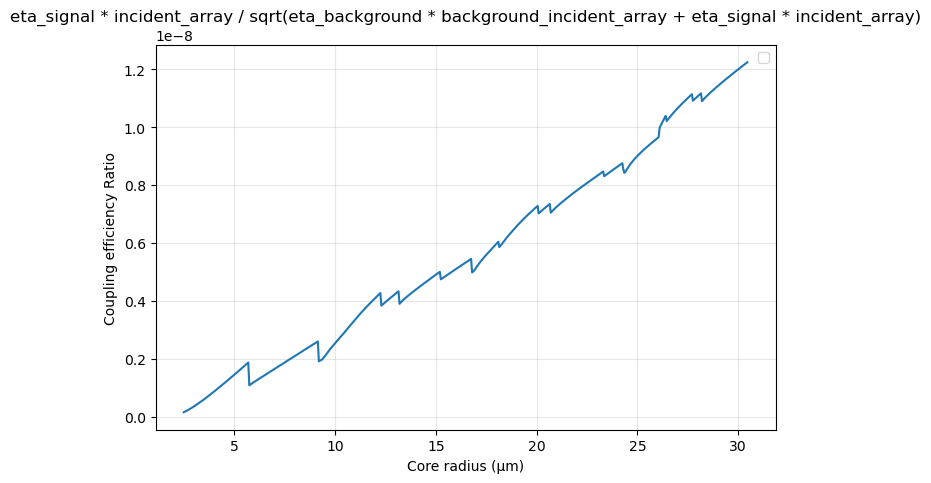

In [67]:
plt.figure(figsize=(8, 5))
plt.plot(a_arr * 1e6, eta_centre_arr * np.pi * (core_radius_arr)**2 / np.sqrt(eta_bg_arr)) # * background_incident_array))
plt.xlabel("Core radius (µm)")
plt.ylabel("Coupling efficiency Ratio")
plt.title("eta_signal * incident_array / sqrt(eta_background * background_incident_array + eta_signal * incident_array)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Text(0.5, 1.0, 'eta_signal / FOV')

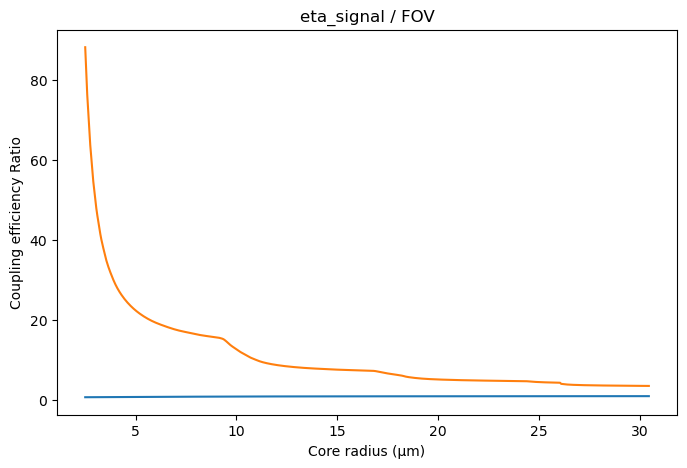

In [69]:
plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, eta_centre_arr)
plt.plot(core_radius_arr * 1e6, 1 /FOV_array)
plt.xlabel("Core radius (μm)")
plt.ylabel("Coupling efficiency Ratio")
plt.title("eta_signal / FOV")

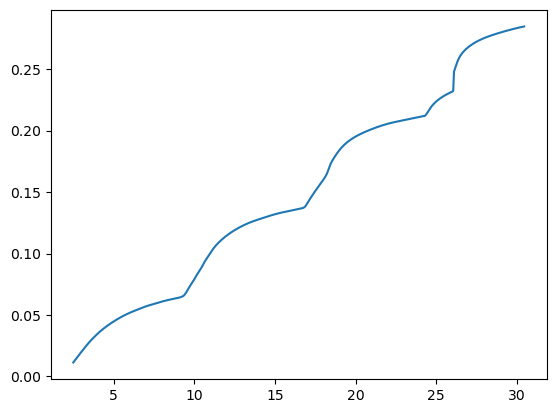

In [70]:
plt.plot(core_radius_arr * 1e6, FOV_array)


In [71]:
# Aperture-only sanity check:
# Point-source signal = fraction of diffraction-limited PSF inside fibre core
# Sky background = uniform surface brightness over fibre FOV area

core_radius_arr = np.array([row["a"] for row in data_few_sym_2d])
F_opt_arr = np.array([row["F_opt"] for row in data_few_sym_2d])

EE_arr = np.zeros_like(core_radius_arr)
FOV_arr = np.zeros_like(core_radius_arr)
snr_aperture_arr = np.zeros_like(core_radius_arr)

F_focus = 49.9
D_M1 = 8.0
rad_to_arcsec = (180 / np.pi) * 3600
plate_scale_coude = rad_to_arcsec / (F_focus * D_M1)  # arcsec / metre

R_grid = np.sqrt(x**2 + y**2)

for i, a in enumerate(core_radius_arr):

    I_image = data_few_sym_2d[i]["I_image_opt"]
    F_opt = F_opt_arr[i]

    # Fibre angular FOV on sky
    magnification = F_opt / F_focus
    plate_scale_fibre = plate_scale_coude / magnification
    FOV = plate_scale_fibre * (2 * a)   # arcsec, diameter
    FOV_arr[i] = FOV

    # Total diffraction-limited point-source power on grid
    P_total_x = integrate.simpson(I_image, x=x_1d, axis=1)
    P_total = integrate.simpson(P_total_x, x=y_1d)

    # Power geometrically inside fibre core only
    aperture_mask = R_grid <= a
    I_inside = np.where(aperture_mask, I_image, 0.0)

    P_inside_x = integrate.simpson(I_inside, x=x_1d, axis=1)
    P_inside = integrate.simpson(P_inside_x, x=y_1d)

    EE = P_inside / P_total
    EE_arr[i] = EE

    # Uniform sky background scales with angular fibre area
    sky_area = np.pi * (FOV / 2)**2

    # Relative aperture-only SNR
    snr_aperture_arr[i] = EE / np.sqrt(Background_incident * eta_bg_arr[i])  # eta_bg_arr[i] is the coupling efficiency for the flat background, which we can use to scale the sky area contribution to the noise.

# Normalise for easier comparison
snr_aperture_rel = snr_aperture_arr 



KeyboardInterrupt: 

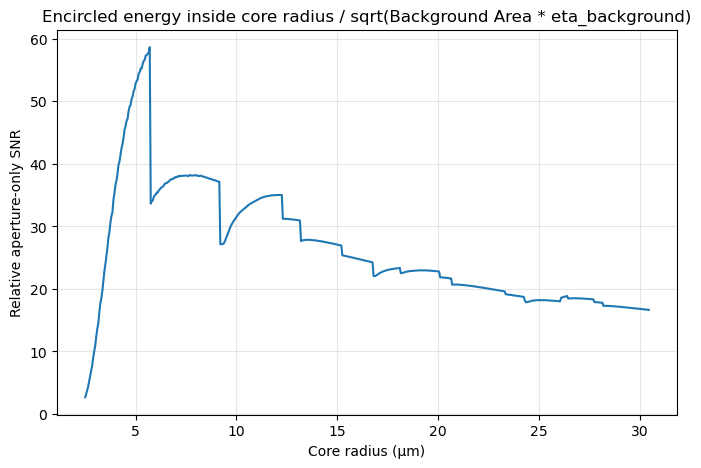

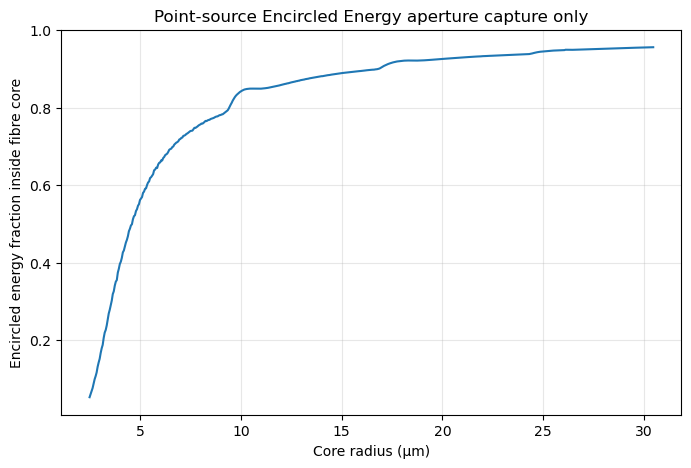

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, snr_aperture_rel)
plt.xlabel("Core radius (µm)")
plt.ylabel("Relative aperture-only SNR")
plt.title("Encircled energy inside core radius / sqrt(Background Area * eta_background)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, EE_arr)
plt.xlabel("Core radius (µm)")
plt.ylabel("Encircled energy fraction inside fibre core")
plt.title("Point-source Encircled Energy aperture capture only")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
core_radius_arr[np.argmax(snr_aperture_rel)]

np.float64(5.699999999999996e-06)

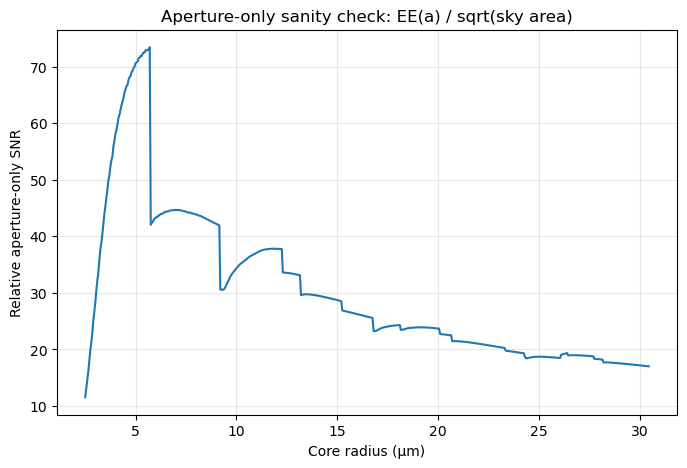

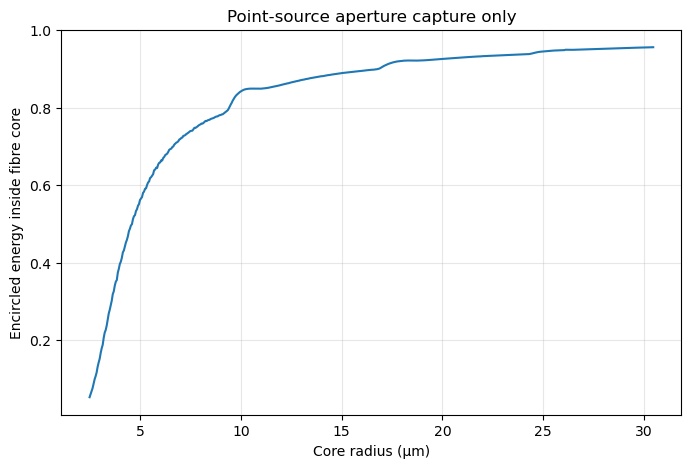

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, snr_aperture_rel / np.sqrt(EE_arr))
plt.xlabel("Core radius (µm)")
plt.ylabel("Relative aperture-only SNR")
plt.title("Aperture-only sanity check: EE(a) / sqrt(sky area)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, EE_arr)
plt.xlabel("Core radius (µm)")
plt.ylabel("Encircled energy inside fibre core")
plt.title("Point-source aperture capture only")
plt.grid(True, alpha=0.3)
plt.show()